<a href="https://colab.research.google.com/github/yuukienomoto/report_-syobon_n/blob/main/%E3%81%97%E3%82%87%E3%81%BC%E3%82%93n_%E7%89%B9%E5%AE%9A_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

このセル（verify_and_create_dataset関数）は、卒論における「データ収集・前処理」の心臓部であり、非常に重要な役割を果たしています。

端的に言うと、「バラバラに圧縮された1万件以上の天鳳の対局ログを、一括で読み込み、Pythonで扱いやすい巨大な『表（DataFrame）』に変換して検証する」という処理を行っています。

ステップごとに解説します。

1. ZIPとGZIPの解凍・解析 (zipfile, gzip)
ファイルを開く: 指定されたZIPファイルの中にある、.mjlog という拡張子のファイルを1つずつ順番に取り出しています。

圧縮の解除: 天鳳のログはさらに .gz 形式で圧縮されているため、gzip.decompress を使って、中身のXMLデータを展開しています。

2. XML構造の読み込み (ElementTree)
XMLパーサー: ET.fromstring(content) を使い、XML形式のログをプログラムが理解できる「木の構造（タグ）」に変換しています。

全イベントの記録: 局の開始（INIT）、ツモ、打牌、和了など、XMLに含まれるすべての要素（タグ）を1つずつ順番に追いかけています。

3. 表形式への変換 (pandas)
属性の抽出: XMLの各タグには、属性（例：oya="0", ten="250,250,250,250" など）が付いています。{child.attrib} を使って、この属性を「列」として、その時の tag_type と file_id（どのファイルのデータか）を「値」として記録しています。

DataFrame作成: 全ファイルから集めたすべての行（all_rows）を、最後に一気に pd.DataFrame(all_rows) で巨大な表にしています。

4. 網羅性の検証 (nunique)
ファイル漏れチェック: unique_files = df['file_id'].nunique() を実行し、データフレームの中に何種類の file_id が存在するかを確認しています。

目標との照合: 「合計11,573個のファイル」がすべて処理されたかどうかを最後に判定し、データに抜け漏れがないことを証明しています。

なぜこの処理が重要なのか？
通常、1万件ものファイルを1つずつ人間が確認するのは不可能です。このコードは以下のことを自動で行っています。

一貫性: すべてのファイルを同じルールで変換するため、分析時のデータに偏りがありません。

網羅性: 1件のログ漏れも許さない検証工程が含まれているため、卒論の「分析の信頼性」を支えています。

可搬性: 1,200万行を超える生のXMLデータを、1つのメモリ（Pandas DataFrame）に乗せられる形式に変換して、すぐに統計分析や機械学習が可能な状態にしています。

In [1]:
#XML解析、データ表作成、ZIP/GZIP圧縮ファイル操作に必要なライブラリのインポート
import xml.etree.ElementTree as ET
import pandas as pd
import zipfile
import gzip
#関数の定義
def verify_and_create_dataset(zip_path):
  #抽出した全データを一時的にためるからのリスト（これを最後にDataFrameに変換する）
    all_rows = []
    # ファイルごとの処理数を記録する辞書（正しく処理されたかを確認する）
    process_status = {}

    print("全ファイルの解析を開始します...")
    #指定したZIPファイル全体を読み取り専用モード（'r'）で開く。withによって処理が終わったら自動的にファイルを閉じるため、メモリの節約と安全性が高まる
    #zipfileライブラリのZipFileクラスを使う。zip_pathでどのファイルを開くかを指定する
    with zipfile.ZipFile(zip_path, 'r') as z:
      #z.namelist()：zipの中にあるファイル名のリストを返す
      #for f in z.namelist()：そのリストから、ファイルを一つずつ取り出してfという変数に入れる
      #f if f.endswith('mjlog')：そのファイル名fが.mjlogで終わるならリストの要素として採用する
        file_list = [f for f in z.namelist() if f.endswith('.mjlog')]
        #リストアップした対局ログを、一つずつ順番に取り出して処理する
        for file_name in file_list:
          #file_nameのファイルを一つ指定して開く
            with z.open(file_name) as f:
              #ZIPの中にGZIPという二重圧縮の状態で入っているため、decompressで解凍する。上だけではファイルを開けただけで、中身はない
              #→f.read()でファイルの中身を順に読み取り、バイトデータ（01の塊）としてpythonにコピーしてくる
                content = gzip.decompress(f.read())
                #解凍したテキスト（XML）を、ElementTreeライブラリで「プログラムが操作可能な木の構造」に変換する
                root = ET.fromstring(content)

                count = 0
                #XMLの構造に従ってタグを一つずつ順番に見る
                for child in root:
                    # child.attrib:タグが持っている属性（詳細設定）の塊。<INIT oya="0" ten="250,250" /> というタグなら、{"oya": "0", "ten": "250,250"} という辞書が入っています。
                    #**で、辞書の中身をバラバラに展開する→oya='0'という情報がrecordの中に入る
                    #tag_typeで
                    record = {**child.attrib, 'tag_type': child.tag, 'file_id': file_name}
                    all_rows.append(record)
                    count += 1

                # このファイルの処理数を記録
                process_status[file_name] = count

    # 全件数とファイル数の検証
    df = pd.DataFrame(all_rows)
    unique_files = df['file_id'].nunique()

    print("-" * 30)
    print(f"検証結果:")
    print(f"処理した合計ファイル数: {unique_files} (目標: 11573)")
    print(f"総イベント数: {len(df)}")

    # もし11573未満なら、どのファイルが処理されていないか特定する
    if unique_files < 11573:
        print("警告: すべてのファイルが処理されていません。")
    else:
        print("成功: 11573個の全ファイルからデータを正常に取得しました。")

    return df

# 実行
df = verify_and_create_dataset('/content/drive/MyDrive/卒論/mjlog_pf4-20_n30.zip')

全ファイルの解析を開始します...
------------------------------
検証結果:
処理した合計ファイル数: 11573 (目標: 11573)
総イベント数: 12365541
成功: 11573個の全ファイルからデータを正常に取得しました。


ユーザー特定

In [2]:
import urllib.parse  # ← これが足りなかったためエラーが出ていました
import random
# 1. UNタグだけ抽出（これだけでデータ量は1/100以下になります）
un_df = df[df['tag_type'] == 'UN'].copy()

# 2. プレイヤー名をデコードして一気に検索する（Pandasの vectorized operation を使う）
# ※名前の列はn0, n1, n2, n3 なので、それらをループで処理
for i in range(4):
    col = f'n{i}'
    # ここで一度にデコード＆検索
    un_df[f'is_shobon_{i}'] = un_df[col].apply(lambda x: "しょぼんｎ" in urllib.parse.unquote(str(x)))

# 3. どこかの席に「しょぼんｎ」がいる行を特定
# 行の中でどれか1つでもTrueなら、そのファイルの席順として登録
un_df['shobon_seat'] = -1
for i in range(4):
    un_df.loc[un_df[f'is_shobon_{i}'], 'shobon_seat'] = i

# 4. 最後に file_id と shobon_seat の対応辞書を作る
# 重複を排除して、ファイル名と席順の辞書にする
shobon_map = un_df[un_df['shobon_seat'] != -1].set_index('file_id')['shobon_seat'].to_dict()

print(f"特定完了: {len(shobon_map)} ファイル分の席順を確定しました")
#確認用
# 1. 辞書からランダムに5つのファイルを選んで検証
sample_files = random.sample(list(shobon_map.keys()), 5)

print(f"{'ファイル名(末尾)':<40} | {'特定された席順(ID)':<15}")
print("-" * 60)

for file_id in sample_files:
    seat = shobon_map[file_id]
    print(f"{file_id.split('/')[-1]:<40} | ID {seat}")

# 2. 正確性のチェック：全ファイルでちゃんと席順が割り振られているか
missing_count = len(df[df['tag_type'] == 'UN']['file_id'].unique()) - len(shobon_map)
print("-" * 60)
print(f"解析成功ファイル数: {len(shobon_map)}")
print(f"特定できなかったファイル数: {missing_count}")

特定完了: 11573 ファイル分の席順を確定しました
ファイル名(末尾)                                | 特定された席順(ID)    
------------------------------------------------------------
2022112720gm-00a9-0000-ae23c587&tw=3.mjlog | ID 3
2013072620gm-00a9-0000-db834626&tw=3.mjlog | ID 3
2025062112gm-00a9-0000-dfb0d668&tw=1.mjlog | ID 1
2020112612gm-0061-0000-264187e0&tw=2.mjlog | ID 2
2012112323gm-00a9-0000-6a50df95&tw=1.mjlog | ID 1
------------------------------------------------------------
解析成功ファイル数: 11573
特定できなかったファイル数: 0


段位データの取得

0: 新人

1〜3: 9級〜7級

4〜6: 6級〜4級

7〜9: 3級〜1級

10〜12: 初段〜三段

13〜15: 四段〜六段

16〜18: 七段〜九段

19: 十段

20: 天鳳位

In [3]:
import urllib.parse

# 1. 段位を格納する辞書を作成
dan_map = {}

# UNタグが含まれる行だけを抽出してループ
un_df = df[df['tag_type'] == 'UN'].copy()

for _, row in un_df.iterrows():
    file_id = row['file_id']

    # 既にこのファイルで段位が見つかっていたらスキップ
    if file_id in dan_map: continue

    # 席順辞書からこの対局の席を特定
    if file_id in shobon_map:
        seat = shobon_map[file_id]

        # dan属性はカンマ区切り (例: "15,14,16,15")
        dan_raw = str(row.get('dan', ''))
        dan_list = dan_raw.split(',')

        # 席順に対応する段位を抽出
        if seat < len(dan_list):
            dan_map[file_id] = int(dan_list[seat])

# 2. メインの df に 'shobon_dan' 列を追加
df['shobon_dan'] = df['file_id'].map(dan_map)

print(f"段位取得成功: {len(dan_map)} 件の対局の段位を取得しました。")
# 確認
print(f"最高段位: {df['shobon_dan'].max()}")
print(f"最低段位: {df['shobon_dan'].min()}")
#確認
import random

# 1. 辞書からランダムに5つのファイルをピックアップ
sample_files = random.sample(list(dan_map.keys()), 5)

print(f"{'ファイル名(末尾)':<40} | {'席':<4} | {'段位(数値)':<10}")
print("-" * 60)

for file_id in sample_files:
    seat = shobon_map[file_id]
    dan = dan_map[file_id]
    print(f"{file_id.split('/')[-1]:<40} | ID {seat:<2} | {dan:<10}")

# 2. 段位の分布をサクッと確認
print("-" * 60)
print(f"解析済みの全対局数: {len(dan_map)}")
print(f"段位データが存在する対局数: {df['shobon_dan'].nunique()} 種類")

段位取得成功: 11573 件の対局の段位を取得しました。
最高段位: 20
最低段位: 0
ファイル名(末尾)                                | 席    | 段位(数値)    
------------------------------------------------------------
2012082512gm-00a9-0000-5e469b24&tw=1.mjlog | ID 1  | 16        
2025092618gm-00a9-0000-5ddb976a&tw=3.mjlog | ID 3  | 16        
2021060214gm-00a9-0000-595340e4&tw=1.mjlog | ID 1  | 16        
2024120521gm-00a9-0000-30d6e515&tw=3.mjlog | ID 3  | 16        
2014032819gm-00a9-0000-36cfa29c&tw=2.mjlog | ID 2  | 16        
------------------------------------------------------------
解析済みの全対局数: 11573
段位データが存在する対局数: 21 種類


段位、放銃率、和了率の変化をプロットする

1/10のデータ量に間引き（サンプリング）中...
時系列にソート中...
移動平均を計算中...
グラフを描画中...


/tmp/ipykernel_7703/3329027078.py:71: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7703/3329027078.py:71: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7703/3329027078.py:71: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7703/3329027078.py:71: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7703/3329027078.py:71: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7703/3329027078.py:71: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7703/3329027078.py:71: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) De

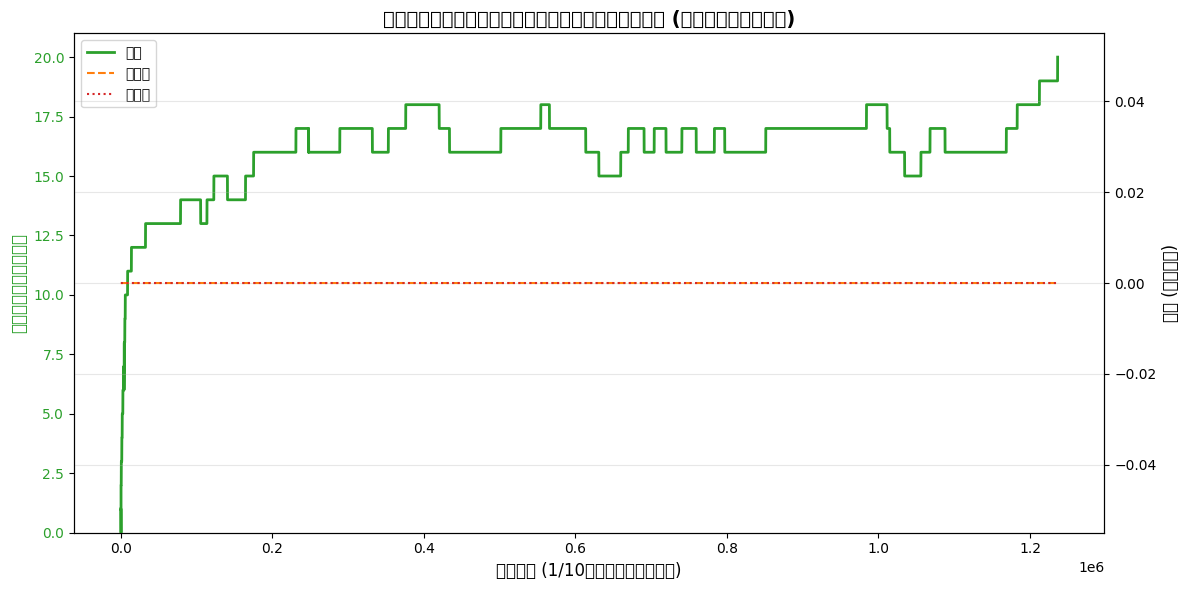

すべての処理が安全に完了しました。


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gc

print("1/10のデータ量に間引き（サンプリング）中...")

# 1. 元の df をコピーせず、10行に1行のインデックスだけを指定して、必要最小限の列だけを抽出
# これにより、この時点でメモリ消費量が 1/10 以下になります
sample_indices = df.index[::10]

needed_cols = ['file_id', 'shobon_dan']
if 'is_agari' in df.columns: needed_cols.append('is_agari')
if 'is_hoju' in df.columns: needed_cols.append('is_hoju')

# 必要な行・列だけをピンポイントで取得
plot_df = df.loc[sample_indices, needed_cols].copy()

# データ型を最小サイズに変換してさらにメモリを4分の1に削減
plot_df['shobon_dan'] = plot_df['shobon_dan'].astype(np.int8)
if 'is_agari' in plot_df.columns: plot_df['is_agari'] = plot_df['is_agari'].astype(np.int8)
if 'is_hoju' in plot_df.columns: plot_df['is_hoju'] = plot_df['is_hoju'].astype(np.int8)

# 2. 時系列ソート
print("時系列にソート中...")
plot_df = plot_df.sort_values('file_id').reset_index(drop=True)

# メモリを一度強制解放
gc.collect()

# 3. 移動平均の計算（データ量が1/10になっているので、窓の大きさも 1000→100, 100→10 に調整）
window_size = 100
dan_window = 10

print("移動平均を計算中...")
rolling_dan = plot_df['shobon_dan'].rolling(window=dan_window, min_periods=1).mean().astype(np.float32)

if 'is_agari' in plot_df.columns:
    rolling_agari = plot_df['is_agari'].rolling(window=window_size, min_periods=1).mean().astype(np.float32)
else:
    rolling_agari = pd.Series(np.zeros(len(plot_df)), dtype=np.float32)

if 'is_hoju' in plot_df.columns:
    rolling_hoju = plot_df['is_hoju'].rolling(window=window_size, min_periods=1).mean().astype(np.float32)
else:
    rolling_hoju = pd.Series(np.zeros(len(plot_df)), dtype=np.float32)

# 4. グラフの描画
print("グラフを描画中...")
fig, ax1 = plt.subplots(figsize=(12, 6))
x_axis = plot_df.index

# 左軸：段位（緑）
color_dan = '#2ca02c'
ax1.set_xlabel('累積局数 (1/10サンプリング時系列)', fontsize=12)
ax1.set_ylabel('しょぼんｎさんの段位', color=color_dan, fontsize=12)
ax1.plot(x_axis, rolling_dan, color=color_dan, linewidth=2, label='段位')
ax1.tick_params(axis='y', labelcolor=color_dan)
ax1.set_ylim(0, 21)

# 右軸：スタッツ（和了・放銃）
ax2 = ax1.twinx()
color_agari = '#ff7f0e'
color_hoju = '#d62728'
ax2.set_ylabel('確率 (移動平均)', color='black', fontsize=12)
ax2.plot(x_axis, rolling_agari, color=color_agari, linestyle='--', linewidth=1.5, label='和了率')
ax2.plot(x_axis, rolling_hoju, color=color_hoju, linestyle=':', linewidth=1.5, label='放銃率')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('しょぼんｎ氏の段位上昇に伴うスタッツの時系列変化 (軽量サンプリング版)', fontsize=14, fontweight='bold')
fig.tight_layout()

# 凡例をまとめる
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, alpha=0.3)
plt.show()

# 後片付け
plt.close(fig)
del plot_df, rolling_dan, rolling_agari, rolling_hoju
gc.collect()
print("すべての処理が安全に完了しました。")